In [1]:
import torch
import triton
import triton.language as tl
DEVICE = torch.device('cuda:0')

In [2]:
# step 1
def naive_sf(x):
  #x.shape = (M, N)

  #read MN and write M (each row has its max)
  x_max = x.max(dim=1)[0]

  #read MN+M elements and write MN, subtraction in MN FLOPS
  z = x - x_max[:,None]

  #read MN and write MN
  numerator = torch.exp(z)

  #read MN elements and write M
  denominator = numerator.sum(1)[:, None]

  #read MN (numerator) + M (denominator) elements, write MN elements, division would be MN FLOPS
  out = numerator/denominator

  return out

  #8MN + 4M memory operations in total and this is slow to make it happen on the GPU as each data needs to be transferred to the GPU


In [8]:
# step 4

@triton.jit
def _softmax_kernel(
    ip_ptr, op_ptr,
    ip_row_stride, op_row_stride,
    n_rows, n_cols,
    BLOCK_SIZE: tl.constexpr,
    num_stages: tl.constexpr
):

  PID = tl.program_id(0)

  #get the total number of programs launched for this kernel
  row_step = tl.num_programs(0)

  # if total programs = 4 => row step = 4

  # if rows < total programs (e.g., rows = 3)
    #then
      #pid 0  -> row 0
      #pid 1 -> row 1
      #pid 2 -> row 2 (completed)
      #pid 3 -> row 3 (n/a)
  # if rows > total programs (e.g., rows = 6)
    #then
      #pid 0 -> row 0
      #pid 1 -> row 1
      #pid 2 -> row 2
      #pid 3 -> row 3 (all programs executed)
      # now,
      #pid 0 += row_step => row 4
      #pid 1 += row_step => row 5 (completed)
      #pid 2 += row_step => row 6 (n/a)
      #pid 3 += row_step => row 7 (n/a)


  for row_idx in tl.range(PID, n_rows, row_step, num_stages=num_stages):
    #A, B, C, D, E --- r0
    #F, G, H, I, J --- r1
    #K, L, M, N, O --- r2

    #A,B,C,D,E,F,G,H,I,J,K,L,M,N,O

    #ip_ptr = address of A
    #row_idx = 2 (let's say)
    #row_step = 5 (each row have 5 elements)

    # => row_start_ptr = address of A + 2*5 = address of A + 10

    #counting 10 elements from A, we land at K which is the start address of row_idx 2
    row_start_ptr = ip_ptr + row_idx * ip_row_stride

    col_offsets = tl.arange(0, BLOCK_SIZE)
    ip_ptrs = row_start_ptr + col_offsets # array of addresses of each element of row 2
    mask = col_offsets < n_cols # mask to avoid any index which is out of bound of the matrix

    #load the row into the SRAM (registers) from DRAM of the SM
    #We are only reading the data once
    row = tl.load(ip_ptrs, mask=mask, other=float("-inf")) #load the row values where mask equals True and put -inf where mask equals False

    row_minus_max = row - tl.max(row, axis=0)
    numerator = tl.exp(row_minus_max)
    denominator = tl.sum(numerator, axis=0)
    sf_out = numerator/denominator

    #fetch the very first address of the row_idx row of the output matrix to write
    output_row_start_ptr = op_ptr + row_idx * op_row_stride

    #writing the row from SRAM to DRAM
    tl.store(output_row_start_ptr + col_offsets, sf_out, mask=mask)

    # this implies there are 2 memory operations in the kernel





In [18]:
# step 3

# fetching the properties of the GPU
properties = triton.runtime.driver.active.utils.get_device_properties(DEVICE.index)
NUM_SM = properties["multiprocessor_count"]
NUM_REGS = properties["max_num_regs"] # total number of registers on a single SM
TOTAL_SRAM_PER_SM = properties["max_shared_mem"]
WARP_SIZE = properties["warpSize"]

#kernel wrapper
def softmax(x):
  assert x.ndim == 2
  n_rows, n_cols = x.shape

  #kernel setup based on the gpu details
  BLOCK_SIZE = triton.next_power_of_2(n_cols) # each separate block (or SM) would handle each element in each row


  #based on the block size, we set the number of warps, now num_warps = 4 means 32 * 4 threads for this kernel since NVIDIA GPU has 32 threads in a single warp
  num_warps = 4
  if BLOCK_SIZE >= 2048:
    num_warps = 8
  if BLOCK_SIZE >= 4096:
    num_warps = 16


  #pipeline --> how many statements can be executed parallely if they are independent
  num_stages = 4 if TOTAL_SRAM_PER_SM >= 200000 else 2


  y = torch.empty_like(x)

  #we gonna do a warmup -> precompile the kernel to know the registeres and sram the kernel is going to need
  kernel = _softmax_kernel.warmup(
      x, y, #ip, op
      x.stride(0), y.stride(0),
      n_rows, n_cols,
      BLOCK_SIZE=BLOCK_SIZE,
      num_stages=num_stages,
      num_warps=num_warps,
      grid=(1,),
  )

  kernel._init_handles()
  n_regs_per_program = kernel.n_regs # how many register the kernel needs per program (single thread)
  sram_needed_per_program = kernel.metadata.shared

  # numerator is the total registers in an SM and denominator is the amount of registers needed per program
  reg_occupancy = NUM_REGS // (n_regs_per_program * WARP_SIZE * num_warps) # number of programs that can fit into an SM

  # how many programs can fit into one SM
  sram_occupancy = TOTAL_SRAM_PER_SM // sram_needed_per_program

  # a program needs both reg and sram in an SM. If reg = 5 and sram = 10; then we would need sram = 5 which is equal to reg.
  programs_per_sm = min(reg_occupancy, sram_occupancy)

  #since we have total SMs and programs running on each SM, we can find the total programs running by total_SM * programs_per_sram
  #since we need each program to manage each row (which has elements equal to the number of columns),
  #so if we have inputs rows less than the space on the GPU, we will not fill up the entire GPU,
  #rather we will run the programs equal to the number of rows in the input
  #likewise, if we have ip rows more than the space on the gpu, we will run the number of programs that can fit
  #that is why 'min' is taken
  num_programs = min(NUM_SM * programs_per_sm, n_rows)

  #number of blocks or program instances inside the grid
  #each instance is responsible to process a single row (batch)
  grid = (num_programs,1,1)

  kernel[grid](
      x, y,
      x.stride(0), y.stride(0),
      n_rows, n_cols,
      BLOCK_SIZE,
      num_stages
  )

  return y


In [19]:
# step 2
def test_softmax_kernel(size:tuple, atol=1e-3, rtol=1e-3, device = DEVICE):
  assert type(size) is tuple and len(size) == 2
  torch.manual_seed(0)
  x = torch.randn(size[0], size[1], device=DEVICE)
  z_tri = softmax(x)
  z_ref = torch.softmax(x, axis=1)
  torch.testing.assert_close(z_ref, z_tri, atol=atol, rtol=rtol)
  print("PASSED")

In [22]:
@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=['N'],
        x_vals=[128 * i for i in range(2, 100)],
        line_arg='provider',
        line_vals=['triton', 'torch'],
        line_names=["Triton", "Torch"],
        styles=[('blue', '-'), ('green', '-')],
        ylabel="GB/s",
        plot_name="softmax-performance",
        args={'M': 4096} # values for function arguments not in x_names
    ))
def benchmark(M, N, provider):
    # making the input data
    x = torch.randn(M, N, device=DEVICE, dtype=torch.float32)

    # these two lines ensure more accurate benchmarks; i usually forget to use them but it's not a big deal
    stream = getattr(torch, DEVICE.type).Stream()
    getattr(torch, DEVICE.type).set_stream(stream)

    if provider == 'torch':
        ms = triton.testing.do_bench(lambda: torch.softmax(x, axis=-1))
    if provider == 'triton':
        ms = triton.testing.do_bench(lambda: softmax(x))
    gbps = lambda ms: 2 * x.numel() * x.element_size() * 1e-9 / (ms * 1e-3)
        # 2 = number of memory operations (1 read + 1 write)
        # x.numel() = number of elements
        # x.element_size() = bytes per element (4 for float32)
        # 1e-9 converts bytes to GB
        # 1e-3 converts milliseconds to seconds
    return gbps(ms)

PASSED


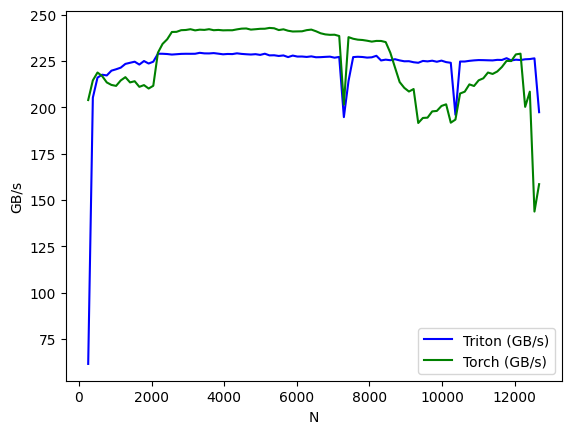

softmax-performance:
          N  Triton (GB/s)  Torch (GB/s)
0     256.0      61.560233    203.894148
1     384.0     205.160140    214.491564
2     512.0     215.966349    218.735755
3     640.0     217.561970    216.834848
4     768.0     217.165652    213.389883
5     896.0     219.732047    212.039690
6    1024.0     220.488984    211.527660
7    1152.0     221.361643    214.465337
8    1280.0     223.381820    216.238349
9    1408.0     223.987948    213.403060
10   1536.0     224.574994    214.036759
11   1664.0     223.025806    211.015986
12   1792.0     224.930016    211.950023
13   1920.0     223.586829    210.100465
14   2048.0     224.568972    211.585868
15   2176.0     228.872028    229.429984
16   2304.0     228.852590    234.174688
17   2432.0     228.710660    236.681327
18   2560.0     228.424961    240.604771
19   2688.0     228.605189    240.680907
20   2816.0     228.793172    241.570630
21   2944.0     228.847551    241.680916
22   3072.0     228.832524    242.09

In [23]:
test_softmax_kernel(size=(1823, 78))
benchmark.run(show_plots=True, print_data=True)